![UTN Facultad Regional Mendoza](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/logo_utn_frm.png)

# Representaciones vectoriales de palabras

**Modelos de Lenguaje · UTN FRM**

Este notebook es el material teórico de la clase de *embeddings*. Se lee y se ejecuta de arriba
abajo: cada idea va acompañada de la celda de código mínima que alcanza para mostrarla, y todas
las celdas están escritas, así que no hay nada que completar.

A continuación va el **Laboratorio 1c**, que trabaja con vectores preentrenados. Esta clase es el
material previo que ese laboratorio da por leído.

## De qué se trata esta clase

Hasta acá el texto se procesó siempre con la misma secuencia de operaciones. Cada reseña se
tokenizó y se convirtió en una secuencia de índices de longitud fija $L$ —recortada o rellenada
según hiciera falta—, y un lote de $B$ reseñas, en un tensor `(B, L)`. Con ese tensor una capa
`nn.Embedding` indexó una tabla de $V \times d$, donde $V$ es la cantidad de tokens del vocabulario
—una fila por token— y $d$ es la cantidad de columnas de esa tabla, es decir la dimensión del
vector que representa a cada palabra. La capa devolvió entonces un tensor `(B, L, d)`; esas filas
se promediaron a lo largo de la dimensión de longitud, excluyendo las posiciones de relleno, para
dar **un vector de $d$ componentes por reseña**; y ese vector fue la entrada de una capa oculta y
una capa de salida. El procedimiento funciona: con esta arquitectura, el clasificador de escenarios
de la Parte B alcanza el 80,0% de *accuracy* sobre el conjunto de prueba.

Queda sin discutir una decisión. Esa tabla se inicializó con valores al azar y sus filas se
ajustaron por descenso de gradiente, como efecto lateral de minimizar el error de clasificación.
En ningún momento se examinó si ese es el mejor procedimiento para determinar sus valores, ni qué
significaría que estuvieran bien determinados.

La clase responde una sola pregunta, y todo lo demás se desprende de ella:

> **¿Qué valores conviene asignarle a cada palabra, y de dónde se obtienen?**

El recorrido son ocho tramos:

| | Tramo | Qué se responde |
|---|---|---|
| 1 | El punto de partida | Qué es la tabla que ya usa el clasificador, y qué ocurriría sin ella |
| 2 | Un vector de rasgos | Qué forma tendría la solución, y por qué no es viable anotarla a mano |
| 3 | La hipótesis distribucional | De dónde se obtiene el significado sin anotación manual |
| 4 | De contar a predecir | El *skip-gram*: el vector como subproducto de una tarea |
| 5 | El muestreo negativo | Cómo se vuelve computable |
| 6 | El entrenamiento sobre el corpus | Los vectores estimados sobre el corpus de reseñas de Amazon |
| 7 | Lo que se usa en la práctica | Vectores preentrenados: *word2vec*, GloVe, *fastText* |
| 8 | El puente al laboratorio | Dos tablas sobre el mismo vocabulario |

Se dan por vistos los contenidos de la Unidad 1 que intervienen acá: tensores y sus formas, la
similitud coseno de la sección *6.2*, `nn.Embedding` dentro del clasificador de la Parte B y el
descenso por gradiente. No se requiere nada más.

In [1]:
import os
import re
import math
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

torch.manual_seed(0)
print(f"Versión de PyTorch: {torch.__version__}")

Versión de PyTorch: 2.11.0


---

## 1. El punto de partida

### 1.1 Lo que hace hoy el clasificador

Conviene tener la arquitectura de la Parte B a la vista, porque esta clase trata exclusivamente de
su primera etapa:

```
(B, L) índices  ──nn.Embedding(V, 64)──▶  (B, L, 64)  ──promedio enmascarado──▶  (B, 64)  ──MLP──▶  logits
```

`nn.Embedding` es una **tabla de $V$ filas y 64 columnas** —una fila por palabra del vocabulario,
es decir $d = 64$— y su única operación es indexarla: devuelve la fila que corresponde a cada
índice. Después el modelo
promedia las filas de las palabras de la reseña, excluyendo las posiciones de relleno, y clasifica
ese promedio.

Es decir que el modelo **ya opera con un vector por palabra**. Lo que queda por determinar es qué
valores conviene que tengan, y para plantear la pregunta con precisión conviene examinar antes el
caso en que la tabla no existe.

### 1.2 La alternativa sin tabla: el *one-hot*

Un vector *one-hot* de tamaño $V$ tiene un 1 en la posición de la palabra y ceros en todas las
demás. Es la representación más directa posible de *"esta palabra es la número 4.312"*, y es la que
habría que usar para representar el índice dentro del modelo sin ninguna tabla de por medio. La Clase 2 ya la
presentó en su sección *4.1*; acá interesa medir su defecto con precisión.

El problema aparece al medir la similitud entre dos de esos vectores. Todos los
*one-hot* son perpendiculares entre sí: comparten exactamente cero posiciones no nulas, así que su
producto punto es 0 y su coseno también.

La celda que sigue lo mide sobre cuatro palabras.

In [2]:
# Cuatro palabras y un vocabulario de juguete de tamaño 6.
demo = ["excelente", "buenísimo", "pésimo", "tornillo"]
V_demo = 6
indices = {"excelente": 0, "buenísimo": 1, "pésimo": 2, "tornillo": 3}

# Un one-hot por palabra: la matriz identidad, recortada.
onehot = torch.zeros(len(demo), V_demo)
for p in demo:
    onehot[demo.index(p), indices[p]] = 1.0

print("los cuatro vectores one-hot:")
for p in demo:
    print(f"  {p:11s} {onehot[demo.index(p)].tolist()}")

print()
print("coseno entre todos los pares:")
for i in range(len(demo)):
    for j in range(i + 1, len(demo)):
        cos = torch.dot(onehot[i], onehot[j]).item()
        print(f"  cos({demo[i]}, {demo[j]}){'':<{22 - len(demo[i]) - len(demo[j])}} = {cos:.1f}")

los cuatro vectores one-hot:
  excelente   [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  buenísimo   [0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
  pésimo      [0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
  tornillo    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0]

coseno entre todos los pares:
  cos(excelente, buenísimo)     = 0.0
  cos(excelente, pésimo)        = 0.0
  cos(excelente, tornillo)      = 0.0
  cos(buenísimo, pésimo)        = 0.0
  cos(buenísimo, tornillo)      = 0.0
  cos(pésimo, tornillo)         = 0.0


Los seis pares dan 0. Para un modelo alimentado con estos vectores, *excelente* está exactamente tan
lejos de *buenísimo* como de *tornillo*, y ninguna cantidad de entrenamiento lo corrige: **la
representación no tiene dónde codificar esa diferencia**. Notá además que ningún par da negativo:
el *one-hot* solo puede expresar "distintas", no "parecidas" ni "opuestas".

La consecuencia práctica es que no habría generalización entre palabras. Un clasificador de
estrellas que hubiera visto mil veces *excelente* en reseñas de 5 estrellas y nunca *buenísimo* no
podría aprovechar nada de lo primero para lo segundo: cada palabra se aprendería desde cero, y las
palabras raras —que son la enorme mayoría del vocabulario— nunca se aprenderían bien.

Un segundo problema, menor pero real: el vector tiene tamaño $V$. Con el vocabulario del corpus de
reseñas que se usa en el tramo 6 —50.000 reseñas, tokens con 10 o más apariciones—, son 7.067
números por palabra, de los cuales 7.066 son cero.

### 1.3 Las dos operaciones son la misma

Buscar la fila número $i$ de una tabla es *exactamente* lo mismo que multiplicar el *one-hot* de $i$
por esa tabla: el *one-hot* selecciona una fila y anula todas las demás. Es la equivalencia de la
sección *4.3* de la Clase 2, y la celda que sigue la vuelve a comprobar porque de ella se desprende
la manera de razonar todo lo que viene después.

In [3]:
tabla = nn.Embedding(V_demo, 4)          # V_demo palabras, 4 columnas

i = torch.tensor([indices["pésimo"]])
por_indice = tabla(i)                    # la capa busca la fila
por_producto = onehot[demo.index("pésimo")] @ tabla.weight   # (V,) @ (V, 4) -> (4,)

print("la tabla entera (V_demo x 4):")
print(tabla.weight.detach().numpy().round(3))
print()
print(f"fila de 'pésimo' buscada por índice:   {por_indice.detach().numpy().round(3)}")
print(f"fila de 'pésimo' por one-hot @ tabla:  {por_producto.detach().numpy().round(3)}")
print(f"¿son la misma?  {torch.allclose(por_indice.squeeze(), por_producto)}")

la tabla entera (V_demo x 4):
[[-1.126 -1.152 -0.251 -0.434]
 [ 0.849  0.692 -0.316 -2.115]
 [ 0.468 -0.158  1.444  0.266]
 [ 0.166  0.874 -0.143 -0.112]
 [ 0.932  1.259  2.005  0.054]
 [ 0.618 -0.413 -0.841 -2.316]]

fila de 'pésimo' buscada por índice:   [[ 0.468 -0.158  1.444  0.266]]
fila de 'pésimo' por one-hot @ tabla:  [ 0.468 -0.158  1.444  0.266]
¿son la misma?  True


![El one-hot como selector de fila](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/01_onehot_selector.png)

Leída de derecha a izquierda, la equivalencia dice que **la tabla es exactamente lo que separa al
modelo del *one-hot***. Sin ella, el modelo recibiría vectores todos equidistantes y no podría
generalizar de una palabra a otra; con ella recibe una fila por palabra, y las filas sí pueden
parecerse entre sí.

El procedimiento que se venía usando era inicializar esa tabla al azar y dejar que el entrenamiento
del clasificador ajustara sus valores. Es una opción entre otras, y no es evidente que sea la
mejor. La pregunta de la clase se puede reformular entonces en términos más concretos:

> **¿Qué valores conviene que tenga cada fila de esa tabla?**

---

## 2. La intuición: un vector de rasgos

Antes de determinar de dónde se obtienen los valores, conviene establecer **qué propiedades
tendrían si fueran los correctos**. La Clase 2 dio una intuición de esto en su sección *4.1*, con
el ejemplo de describir a una persona por cuán introvertida y cuán amable es; acá se la lleva hasta
el final, asignando los valores a mano.

Supongamos que un anotador le asigna a cada palabra un valor en cuatro rasgos: si designa algo que
se bebe, si designa un aparato, cuál es su polaridad y si se refiere a dinero. Cada palabra queda
representada por un vector de cuatro componentes, y la similitud entre dos palabras se vuelve
medible.

In [4]:
# Cuatro rasgos, anotados a mano, en una escala de -1 a 1.
rasgos = ["se bebe", "es un aparato", "polaridad", "habla de dinero"]
anotado = {
    "café":      [ 1.0,  0.0,  0.3,  0.0],
    "té":        [ 1.0,  0.0,  0.2,  0.0],
    "teléfono":  [ 0.0,  1.0,  0.0,  0.2],
    "batería":   [ 0.0,  1.0,  0.0,  0.0],
    "excelente": [ 0.0,  0.0,  1.0,  0.0],
    "pésimo":    [ 0.0,  0.0, -1.0,  0.0],
    "caro":      [ 0.0,  0.0, -0.3,  1.0],
}

E_mano = torch.tensor([anotado[p] for p in anotado])
E_mano = E_mano / E_mano.norm(dim=1, keepdim=True)      # normalizamos: todo es coseno
nombres = list(anotado)


def cos_mano(a, b):
    return torch.dot(E_mano[nombres.index(a)], E_mano[nombres.index(b)]).item()


print(f"{'':12s} " + " ".join(f"{r:>17s}" for r in rasgos))
for p in nombres:
    print(f"{p:12s} " + " ".join(f"{v:>17.1f}" for v in anotado[p]))

print()
for a, b in [("café", "té"), ("teléfono", "batería"), ("excelente", "pésimo"),
             ("café", "teléfono"), ("excelente", "caro")]:
    print(f"  cos({a}, {b}){'':<{20 - len(a) - len(b)}} = {cos_mano(a, b):+.3f}")

                       se bebe     es un aparato         polaridad   habla de dinero
café                       1.0               0.0               0.3               0.0
té                         1.0               0.0               0.2               0.0
teléfono                   0.0               1.0               0.0               0.2
batería                    0.0               1.0               0.0               0.0
excelente                  0.0               0.0               1.0               0.0
pésimo                     0.0               0.0              -1.0               0.0
caro                       0.0               0.0              -0.3               1.0

  cos(café, té)               = +0.996
  cos(teléfono, batería)      = +0.981
  cos(excelente, pésimo)      = -1.000
  cos(café, teléfono)         = +0.000
  cos(excelente, caro)        = -0.287


Con esos números, *café* y *té* son prácticamente el mismo vector (0,996), *excelente* y *pésimo*
apuntan en direcciones **opuestas** —el coseno es −1, no cero: la representación distingue
"contrario" de "no relacionado"—, y *café* y *teléfono* dan exactamente 0, que es lo mismo que daba
el *one-hot*, solo que acá lo dan porque efectivamente no comparten ningún rasgo. Nada de esto se
podía expresar antes.

Aparece además una propiedad nueva: **los rasgos son compartidos**. Si el clasificador aprende que
un valor alto en la coordenada "polaridad" aumenta la puntuación de la clase 5 estrellas, ese
ajuste vale para *excelente*, para *buenísimo* y para cualquier palabra con esa coordenada alta, la
haya visto o no. La generalización entre palabras, imposible con el *one-hot*, acá es inmediata.

![La tabla de rasgos](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/02_tabla_rasgos.png)

### 2.1 Por qué esto no se hace

La tabla de arriba tiene siete filas y cuatro columnas, y completarla es inmediato. La tabla que
hace falta en la práctica tiene una fila por token del vocabulario —**7.067** en el corpus del
tramo 6— y presenta tres problemas, en orden creciente de gravedad:

1. **El costo de anotación es prohibitivo.** Son miles de palabras, y el trabajo se rehace entero
   para cada idioma y cada dominio.
2. **No hay criterio para elegir las columnas.** "Se bebe" y "polaridad" son rasgos elegidos sin
   ningún fundamento; nada garantiza que sean los que un modelo necesita, ni que cuatro alcancen.
3. **Los rasgos relevantes pueden no ser nombrables.** La diferencia entre *devolver* y *cambiar*
   en una reseña existe, pero no corresponde a ninguna categoría que un anotador hubiera previsto.

Los tres se resuelven con la misma decisión: **que las columnas no se elijan y que los valores se
estimen a partir del texto**. Para eso hace falta una hipótesis sobre dónde está el significado en
un corpus.

---

## 3. La hipótesis distribucional

La hipótesis proviene de la lingüística de los años cincuenta, de Zellig Harris y de John Firth, y
se enuncia en una línea:

> **Las palabras que aparecen en contextos parecidos tienen significados parecidos.**

La formulación de Firth es la que se cita siempre: *"conocerás una palabra por la compañía que
tiene"*.

Es una hipótesis, no un teorema, y su plausibilidad se aprecia con un ejemplo. En *"me tomé un
____ bien caliente antes de salir"*, el hueco admite *café*, *té*, *mate* o *caldo*, y no admite
*teléfono* ni *jueves*. Las palabras que pueden ocupar los mismos huecos comparten alguna
propiedad, y esa propiedad se aproxima a lo que se entiende por significado.

![La hipótesis distribucional](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/03_hipotesis_distribucional.png)

Lo importante de la hipótesis es que es **operativa**: dice que el significado de una palabra está
en la lista de palabras que la rodean, y esa lista sí se puede contar automáticamente sobre un
corpus. No requiere anotación manual.

### 3.1 Contar la compañía

La forma más directa de aplicarla es elegir un tamaño de ventana, recorrer el corpus y contar
cuántas veces cada palabra aparece dentro de la ventana de cada otra. Eso da una **matriz de co-ocurrencia** $C$ de
$V \times V$, donde $C_{ij}$ es la cantidad de veces que la palabra $j$ apareció en la ventana de la
palabra $i$.

Y entonces la fila $i$ de esa matriz **es** el vector de la palabra $i$: no un vector de rasgos
anotados, sino un vector de "con quién aparece".

El cálculo se hace sobre un corpus de juguete de doce oraciones, construido de manera que el
efecto se observe sin ambigüedad; las mismas cuentas sobre el corpus real van en el tramo 6.

In [5]:
corpus_juguete = [
    "me tomo un café caliente por la mañana",
    "me tomo un té caliente por la mañana",
    "el café estaba muy caliente y muy rico",
    "el té estaba muy caliente y muy rico",
    "prefiero el café con leche y azúcar",
    "prefiero el té con limón y azúcar",
    "un café bien cargado me despierta",
    "el teléfono es caro pero la batería dura mucho",
    "el teléfono es barato pero la batería dura poco",
    "compré un teléfono caro y me funciona bien",
    "compré un teléfono barato y me funciona mal",
    "un teléfono barato no siempre es peor",
]

tok = lambda t: re.findall(r"\w+", t.lower())
oraciones = [tok(o) for o in corpus_juguete]

palabras_j = sorted({p for o in oraciones for p in o})
idx_j = {p: i for i, p in enumerate(palabras_j)}
V_j = len(palabras_j)

VENTANA = 2
C = np.zeros((V_j, V_j), dtype=int)
for o in oraciones:
    ids = [idx_j[p] for p in o]
    for i, centro in enumerate(ids):
        for j in range(max(0, i - VENTANA), min(len(ids), i + VENTANA + 1)):
            if j != i:
                C[centro, ids[j]] += 1

print(f"{len(oraciones)} oraciones, {sum(len(o) for o in oraciones)} tokens, "
      f"vocabulario de {V_j} tokens distintos")
print(f"matriz de co-ocurrencia: {C.shape}, ventana ±{VENTANA}")
print()

# Las filas de 'café' y de 'té', en texto: con quién aparece cada una.
for p in ["café", "té"]:
    fila = {palabras_j[j]: int(C[idx_j[p], j]) for j in range(V_j) if C[idx_j[p], j]}
    print(f"fila de {p!r}:")
    print("  ", fila)

12 oraciones, 93 tokens, vocabulario de 37 tokens distintos
matriz de co-ocurrencia: (37, 37), ventana ±2

fila de 'café':
   {'bien': 1, 'caliente': 1, 'cargado': 1, 'con': 1, 'el': 2, 'estaba': 1, 'leche': 1, 'muy': 1, 'por': 1, 'prefiero': 1, 'tomo': 1, 'un': 2}
fila de 'té':
   {'caliente': 1, 'con': 1, 'el': 2, 'estaba': 1, 'limón': 1, 'muy': 1, 'por': 1, 'prefiero': 1, 'tomo': 1, 'un': 1}


Las dos filas son casi la misma. Comparten nueve contextos —*tomo*, *un*, *el*, *caliente*,
*estaba*, *muy*, *por*, *con* y *prefiero*— y difieren en cuatro: *leche* contra *limón*, y *café*
suma *bien* y *cargado*, que vienen de una oración adicional. Es la hipótesis distribucional en
funcionamiento: nada en el corpus declara que *café* y *té* sean parecidos, y sin embargo sus filas
lo son.

![La ventana deslizándose](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/04_ventana.png)

### 3.2 Medir el parecido

"Casi la misma fila" hay que convertirlo en un número, y el número es el de la sección *6.2* de la
Unidad 1: el **coseno** entre las dos filas. Se normaliza cada fila y se multiplica la matriz por
su transpuesta, lo que da de una sola vez los cosenos de todos los pares.

In [6]:
M = torch.tensor(C, dtype=torch.float)
M = M / M.norm(dim=1, keepdim=True).clamp(min=1e-9)
S = M @ M.T                                  # (V_j, V_j): todos los cosenos


def vecinos_j(p, k=4):
    """Las k palabras de coseno más alto con p, en el corpus juguete."""
    s = S[idx_j[p]].clone()
    s[idx_j[p]] = -1                         # una palabra no es vecina de sí misma
    return [(palabras_j[i], round(s[i].item(), 2)) for i in s.topk(k).indices]


for p in ["café", "té", "caro", "barato", "batería"]:
    print(f"  {p:9s} -> {vecinos_j(p)}")

print()
for a, b in [("café", "té"), ("caro", "barato"), ("mucho", "poco"),
             ("café", "teléfono"), ("teléfono", "batería")]:
    print(f"  cos({a}, {b}){'':<{20 - len(a) - len(b)}} = {S[idx_j[a], idx_j[b]].item():.3f}")

# ─── Los cinco cosenos más altos de toda la matriz ──────────────────────────
print()
print("los 5 pares de coseno más alto, sobre los 666 pares posibles:")
S_sin_diag = S.clone().fill_diagonal_(-1)
vistos = set()
for k in S_sin_diag.flatten().topk(12).indices.tolist():
    i, j = k // V_j, k % V_j
    par = tuple(sorted((palabras_j[i], palabras_j[j])))
    if par in vistos:
        continue
    vistos.add(par)
    print(f"  {par[0]:10s} {par[1]:10s} {S[i, j].item():.3f}")
    if len(vistos) == 5:
        break

  café      -> [('té', 0.85), ('estaba', 0.5), ('caliente', 0.46), ('me', 0.42)]
  té        -> [('café', 0.85), ('estaba', 0.59), ('prefiero', 0.45), ('caliente', 0.45)]
  caro      -> [('barato', 0.92), ('compré', 0.67), ('no', 0.47), ('es', 0.46)]
  barato    -> [('caro', 0.92), ('compré', 0.79), ('no', 0.56), ('es', 0.54)]
  batería   -> [('dura', 0.51), ('la', 0.42), ('poco', 0.38), ('mucho', 0.38)]

  cos(café, té)               = 0.850
  cos(caro, barato)           = 0.919
  cos(mucho, poco)            = 1.000
  cos(café, teléfono)         = 0.377
  cos(teléfono, batería)      = 0.000

los 5 pares de coseno más alto, sobre los 666 pares posibles:
  mucho      poco       1.000
  barato     caro       0.919
  café       té         0.850
  barato     compré     0.791
  bien       tomo       0.783


El resultado principal está en la primera línea de cada bloque: el vecino más cercano de *café* es
*té* y el de *té* es *café*, con coseno 0,850, contra 0,50 y 0,59 de sus respectivos segundos
vecinos. Contando co-ocurrencias sobre doce oraciones y sin anotar un solo rasgo, aparece una
relación semántica.

Ahora los tres problemas, que son los que motivan todo lo que sigue.

**1. `cos(teléfono, batería) = 0,000`.** Las dos palabras aparecen en las mismas oraciones, pero
nunca dentro de la ventana de la otra: sus filas no comparten ni una posición. La similitud
distribucional **no** es "aparecer en el mismo tema", es "aparecer rodeado de las mismas palabras",
que es otra cosa. Es una distinción que conviene tener presente al interpretar vecinos más
adelante.

**2. Los dos cosenos más altos de toda la matriz son pares de antónimos.** `mucho`/`poco` da 1,000
y `caro`/`barato` da 0,919, los dos por encima de `café`/`té`, que da 0,850. No es un error de
implementación ni algo que se arregle con más datos: es un **límite de la hipótesis**. Los antónimos
son justamente las palabras que se usan en el mismo lugar de la misma oración —*el teléfono es
caro* / *el teléfono es barato*—, así que comparten contexto casi perfectamente. La señal
distribucional no distingue "opuesto" de "parecido": desde los contextos, las dos relaciones son
indistinguibles. Este resultado vuelve a aparecer, con otro método y sobre el corpus real, en el
tramo 6.

**3. La matriz es de $V \times V$ y está casi toda en cero.** Con doce oraciones es de
$37 \times 37$ y se puede imprimir; con el vocabulario del corpus de reseñas del tramo 6 sería de
$7.067 \times 7.067$, casi 50 millones de celdas, y la enorme mayoría valdría cero. Además, los
conteos crudos están dominados por las palabras más frecuentes: *el*, *de* y *un* co-ocurren con
todo, así que aportan mucho al coseno y nada al significado.

El problema 3 tiene soluciones conocidas —pesar los conteos con PMI en vez de usarlos crudos, y
comprimir la matriz a unas pocas dimensiones con una descomposición—, y esa familia de métodos
funciona. Pero hay un procedimiento distinto, de menor costo computacional y mejores resultados,
que es el que se impuso.

---

## 4. De contar a predecir: el *skip-gram*

El cambio de enfoque es el siguiente. En vez de **contar** contextos y después comprimir la tabla
de conteos, se plantea una **tarea de predicción** sobre el corpus, se la resuelve con una red
mínima y se conservan los parámetros que la red tuvo que ajustar para resolverla.

La tarea, que es la de *word2vec* en su variante *skip-gram*:

> Dada una palabra, predecir cuáles son sus vecinas.

Es decir: dada *batería*, el modelo tiene que asignarle probabilidad alta a *dura*, *carga* o
*autonomía*, y baja a *azúcar* o *camiseta*. Los ejemplos de entrenamiento son pares (centro,
contexto) extraídos del corpus con el mismo recorrido por ventana del tramo anterior: donde antes
se sumaba 1 en una celda de $C$, ahora se emite un par.

El punto importante es que **no hay etiquetado manual**. Las respuestas correctas ya están en el
texto. Es lo que se llama una tarea *autosupervisada*: la supervisión se obtiene del propio dato.

![El skip-gram](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/05_skipgram.png)

### 4.1 El modelo: dos tablas y un producto punto

El modelo es notablemente simple. Tiene **dos** tablas de $V \times d$:

- $\mathbf{v}_w$, la fila de $w$ en la tabla de **centros**: la representación de $w$ cuando actúa
  de palabra central.
- $\mathbf{u}_w$, la fila de $w$ en la tabla de **contextos**: la representación de $w$ cuando
  actúa de vecina.

Y la puntuación que le da al par (centro $c$, contexto $x$) es un producto punto:

$$s(c, x) = \mathbf{v}_c \cdot \mathbf{u}_x$$

Nada más: ni capas ocultas ni no linealidades. El entrenamiento aumenta la puntuación de los pares
presentes en el corpus y disminuye la del resto, y la única manera de conseguirlo es **ajustar las
filas**: dos palabras que aparecen con las mismas vecinas terminan con vectores parecidos, porque
ambas tienen que dar productos punto altos contra los mismos $\mathbf{u}$.

¿Por qué dos tablas y no una? Con una sola, la puntuación de una palabra consigo misma sería
$\mathbf{v}_w \cdot \mathbf{v}_w = \lVert \mathbf{v}_w \rVert^2$, siempre positiva y creciente con
la norma, y el modelo tendría un incentivo permanente a aumentar la norma de los vectores. Separar
los dos roles elimina ese incentivo y permite que el vector con el que una palabra predice y el
vector con el que es predicha no coincidan.

### 4.2 El vector es un subproducto

Terminado el entrenamiento, **el clasificador se descarta**. Predecir vecinas no es el objetivo,
sino el medio. Lo que se conserva es la tabla de centros $\mathbf{v}$, que queda con una fila por
palabra y con las palabras de contextos parecidos próximas entre sí. La tabla de contextos también
se descarta, por convención.

Esa inversión —entrenar un modelo para conservar sus pesos y no sus predicciones— es una idea que
vas a volver a encontrar en la materia. Es, esencialmente, lo que hace un modelo de
lenguaje moderno.

### 4.3 La variante inversa: CBOW

*word2vec* tiene dos variantes, y la segunda invierte la tarea. **CBOW** (*continuous bag of
words*) predice **la palabra central a partir de sus vecinas**, en vez de las vecinas a partir de
la central. Entrena más rápido, porque cada ventana produce un solo ejemplo en vez de varios, y
funciona algo mejor con las palabras frecuentes; el *skip-gram* funciona mejor con las raras y con
corpus chicos, y por eso se usa más. Conceptualmente no altera nada de lo dicho.

---

## 5. El muestreo negativo: de $V$ clases a una pregunta de sí o no

Queda un problema, y es de costo computacional. Tal como está planteada, la tarea *"dada la
central, predecir la vecina"* es una clasificación con $V$ clases: para convertir las puntuaciones
en probabilidades hay que aplicar *softmax* sobre las $V$ palabras del vocabulario. Eso significa
calcular el producto punto de $\mathbf{v}_c$ contra **todas** las filas de la tabla de contextos, y
hacerlo una vez por cada par de entrenamiento. Con los 7.067 tokens del vocabulario y los 1,84 millones de pares
del tramo 6 son $1{,}3 \times 10^{10}$ productos punto por época, y el corpus completo los
multiplica por cuatro.

La solución es cambiar la pregunta. En vez de

> ¿cuál de las $V$ palabras del vocabulario es la vecina?

se pregunta

> este par (centro, contexto), ¿es un par real del corpus o uno fabricado?

Eso es una clasificación **binaria**, y para responderla alcanza con una sigmoide sobre el producto
punto del par. El costo deja de depender de $V$.

Para que la pregunta tenga sentido hacen falta ejemplos de las dos clases. Los positivos son los
pares del corpus. Los negativos se fabrican: por cada par real se sortean $K$
palabras del vocabulario, típicamente $K = 5$, y se arman $K$ pares falsos con la misma palabra
central. El modelo tiene entonces que aumentar la puntuación del par real y disminuir la de los
cinco falsos, que es un cálculo sobre 6 filas en vez de sobre 7.067.

![El muestreo negativo](https://raw.githubusercontent.com/javovelez/Modelos-de-Lenguaje/main/img/06_muestreo_negativo.png)

### 5.1 De qué distribución se sortean los falsos

Queda una decisión: cómo se eligen esas $K$ palabras. Ni uniformemente ni con la frecuencia real del
corpus, sino con la frecuencia elevada a $3/4$ y renormalizada:

$$P_{\text{neg}}(w) = \frac{f(w)^{3/4}}{\sum_{w'} f(w')^{3/4}}$$

El exponente es un valor empírico del artículo original, y su efecto es **aplanar** la
distribución: traslada masa de probabilidad de las palabras muy frecuentes a las raras, sin llegar
a la uniforme. La tabla del tramo 6 lo cuantifica: *de* se sortea 0,41 veces lo que le
correspondería por frecuencia y *tallaje*, 2,07 veces.

El fundamento es el siguiente. Si los negativos se sortearan con la frecuencia real, casi todos
serían *de*, *que* o *la*, y distinguirlos del contexto verdadero sería trivial: el modelo
aprendería a detectar palabras vacías en lugar de significado. Si se sortearan uniformemente, casi
todos serían palabras muy raras, y la tarea también sería trivial. El $3/4$ es el punto intermedio
en el que la tarea resulta difícil, que es la condición para que el modelo aprenda algo.

Con esto el método queda completo. Lo que sigue es ejecutarlo sobre el corpus.

---

## 6. El entrenamiento sobre el corpus

Lo que sigue entrena el *skip-gram* con muestreo negativo sobre reseñas reales de Amazon en
español y examina los vectores que resultan. Son seis celdas de código y menos de un minuto de
cómputo en CPU.

El tramo no introduce ningún concepto nuevo: es la implementación de los tramos 4 y 5. Si el tiempo
de la clase no alcanza, se puede leer sin ejecutar.

### 6.1 El corpus

Son las mismas reseñas de la Unidad 1 y del laboratorio: 200.000 reseñas de productos en español,
etiquetadas con la cantidad de estrellas. Las estrellas no intervienen acá —el *skip-gram* no las
usa—; lo único que interviene es el texto.

El tramo trabaja sobre un **recorte de 50.000 reseñas**, que da 1.556.230 tokens de texto y un vocabulario
de 7.067 tokens distintos. La constante `N_RESENAS` es lo único que hay que cambiar para entrenar sobre el
corpus completo: con el valor `None` el notebook usa las 200.000, lo que multiplica por cuatro la
cantidad de pares y el tiempo de entrenamiento.

La celda deja construido `vocab`, el vocabulario armado con el mismo tokenizador y la misma clase
que usan los laboratorios.

In [7]:
N_RESENAS = 50_000        # None = las 200.000 (cuatro veces más pares y más tiempo)
DIM = 100                 # columnas de la tabla de embeddings

# ─── El corpus ──────────────────────────────────────────────────────────────
URL_CORPUS = ("https://github.com/javovelez/Modelos-de-Lenguaje/releases/download"
              "/corpus-v1/amazon_reviews_es.parquet")
ARCHIVO = "amazon_reviews_es.parquet"

if not os.path.exists(ARCHIVO):
    urllib.request.urlretrieve(URL_CORPUS, ARCHIVO)

train = pd.read_parquet(ARCHIVO).query("split == 'train'").reset_index(drop=True)
if N_RESENAS is not None:
    train = train.sample(n=N_RESENAS, random_state=0).reset_index(drop=True)

# ─── El tokenizador y el vocabulario ────────────────────────────────────────
URL_PIPELINE = ("https://github.com/javovelez/Modelos-de-Lenguaje/releases/download"
                "/utils-v1/lab1a_pipeline.py")
if not os.path.exists("lab1a_pipeline.py"):
    urllib.request.urlretrieve(URL_PIPELINE, "lab1a_pipeline.py")

from lab1a_pipeline import tok_simple, Vocabulario

vocab = Vocabulario(train.text, tokenizador=tok_simple, freq_min=10)
V = len(vocab)

corpus = [vocab.codificar(t) for t in train.text]
n_tokens = sum(len(c) for c in corpus)

print(f"reseñas:      {len(train):>10,}")
print(f"tokens:       {n_tokens:>10,}")
print(f"vocabulario:  {V:>10,}  (tokens con 10 o más apariciones, más <pad> y <unk>)")
print()
print("una reseña, tal como la ve el modelo:")
print(" ", " ".join(vocab.itos[i] for i in corpus[0][:30]), "...")

reseñas:          50,000
tokens:        1,556,230
vocabulario:       7,067  (tokens con 10 o más apariciones, más <pad> y <unk>)

una reseña, tal como la ve el modelo:
  una buena idea pero <unk> de mala calidad es una idea de producto estupenda pero <unk> con un plastico de malisima calidad se me han roto casi todos hasta fecha ...


### 6.2 Submuestreo: descartar las apariciones que no informan

Antes de extraer los pares hay un paso que el tramo 5 no mencionó y que en la práctica tiene un
efecto grande. Las palabras más frecuentes —*de*, *que*, *la*, *muy*— aparecen en el contexto de
todo, así que un par (*batería*, *de*) casi no aporta información sobre *batería*. Y son tantas que
dominarían el entrenamiento: las seis palabras más frecuentes concentran el 18,7% de los tokens.

El artículo original de *word2vec* las descarta al azar, con una probabilidad que crece con la
frecuencia:

$$P(\text{descartar } w) = \max\left(0,\; 1 - \sqrt{\frac{t}{f(w)}}\right)$$

con $t = 10^{-4}$. Las palabras con frecuencia relativa menor que $t$ no se descartan nunca; las
muy frecuentes se descartan casi siempre: *de* con probabilidad 0,947 y *excelente* con 0,554,
mientras que *tallaje* no se descarta nunca. Notá que **ningún token sale del vocabulario**: se
descartan *apariciones*, no entradas del vocabulario, y el corpus pasa de 1.556.230 a 539.340 tokens, el 34,7%. Hay
además un efecto secundario buscado: al descartar apariciones, la ventana se extiende y alcanza
palabras de contenido que antes quedaban fuera.

In [8]:
T_SUB = 1e-4

frec = np.zeros(V)
for c in corpus:
    np.add.at(frec, c, 1)                    # acumula sin bucle de Python
p_relativa = frec / frec.sum()

with np.errstate(divide="ignore", invalid="ignore"):
    p_descartar = np.maximum(
        0.0, 1.0 - np.sqrt(T_SUB / np.maximum(p_relativa, 1e-12)))

rng = np.random.default_rng(0)
corpus_sub = []
for c in corpus:
    if not c:
        continue
    a = np.asarray(c)
    sobreviven = a[rng.random(len(a)) > p_descartar[a]]
    if len(sobreviven) >= 2:                 # con menos de 2 tokens no hay ningún par
        corpus_sub.append(sobreviven)

n_despues = sum(len(c) for c in corpus_sub)
print(f"tokens antes:   {n_tokens:>10,}")
print(f"tokens después: {n_despues:>10,}   ({n_despues / n_tokens:.1%} sobrevive)")
print()

print(f"{'palabra':14s} {'apariciones':>12s} {'p(descartar)':>14s}")
print("-" * 42)
frecuentes = [vocab.itos[i] for i in np.argsort(-frec)
              if i not in (vocab.pad_id, vocab.unk_id)][:6]
for p in frecuentes + ["batería", "excelente", "tallaje"]:
    i = vocab[p]
    print(f"{p:14s} {int(frec[i]):>12,} {p_descartar[i]:>13.1%}")

tokens antes:    1,556,230
tokens después:    539,340   (34.7% sobrevive)

palabra         apariciones   p(descartar)
------------------------------------------
de                   55,329         94.7%
que                  49,979         94.4%
y                    49,110         94.4%
la                   46,620         94.2%
no                   46,454         94.2%
el                   43,684         94.0%
batería               1,024         61.0%
excelente               783         55.4%
tallaje                  87          0.0%


### 6.3 Los pares

El recorrido con la ventana, con una diferencia respecto del tramo 3: el tamaño de la ventana **se
sortea** para cada posición, entre 1 y un máximo. No es una arbitrariedad de implementación, sino
un esquema de pesos por cercanía expresado como sorteo: con máximo 3, una vecina inmediata queda
incluida en los tres tamaños posibles y una a distancia 3, en uno solo, de modo que las palabras
cercanas pesan el triple sin ninguna línea de código adicional.

La celda imprime al final los primeros pares en texto. Sin esa verificación no hay manera de saber
si la ventana quedó bien definida, y un error de índice acá no produce ninguna falla visible: el
entrenamiento corre igual y estima vectores peores, que es la peor clase de error posible.

In [9]:
VENTANA_MAX = 3

t0 = time.time()
centros, contextos = [], []
for s in corpus_sub:
    n = len(s)
    ventanas = rng.integers(1, VENTANA_MAX + 1, size=n)     # una por posición
    for i in range(n):
        w = ventanas[i]
        for j in range(max(0, i - w), min(n, i + w + 1)):
            if j != i:
                centros.append(s[i])
                contextos.append(s[j])

centros = np.asarray(centros, dtype=np.int64)
contextos = np.asarray(contextos, dtype=np.int64)

print(f"pares generados: {len(centros):,}   ({time.time() - t0:.1f} s)")
print(f"pares por token: {len(centros) / n_despues:.1f}")
print()
print("la primera reseña, ya submuestreada:")
print(" ", " ".join(vocab.itos[i] for i in corpus_sub[0]))
print()
print("sus primeros 8 pares:")
for c_i, x_i in zip(centros[:8], contextos[:8]):
    print(f"   centro={vocab.itos[c_i]:<14s} contexto={vocab.itos[x_i]}")

pares generados: 1,836,589   (0.8 s)
pares por token: 3.4

la primera reseña, ya submuestreada:
  una idea estupenda plastico malisima casi todos hasta fecha raja plasticos

sus primeros 8 pares:
   centro=una            contexto=idea
   centro=idea           contexto=una
   centro=idea           contexto=estupenda
   centro=estupenda      contexto=una
   centro=estupenda      contexto=idea
   centro=estupenda      contexto=plastico
   centro=estupenda      contexto=malisima
   centro=estupenda      contexto=casi


### 6.4 Los negativos y el modelo

Dos partes en una celda. Primero la distribución $f(w)^{3/4}$ del tramo 5, con la tabla que
cuantifica el efecto del exponente: la última columna es la razón entre la probabilidad de sorteo y
la frecuencia real, y se lee como "cuántas veces más (o menos) de lo que le correspondería".

Después el modelo —las dos tablas y el producto punto— y una **verificación previa al
entrenamiento**. La tabla de contextos se inicializa en cero, así que todos los productos punto dan
0, la sigmoide de 0 da 0,5, y la entropía cruzada binaria de una predicción de 0,5 es
$\ln 2 \approx 0{,}6931$ cualquiera sea la etiqueta. Si el valor no coincide, hay un error en el
armado, y conviene detectarlo en este punto y no después, examinando vectores mal estimados sin
saber por qué.

In [10]:
K = 5                                        # negativos por cada positivo

# ─── La distribución de los negativos ───────────────────────────────────────
pesos_neg = torch.tensor(frec ** 0.75, dtype=torch.float)
pesos_neg[vocab.pad_id] = 0.0                # <pad> y <unk> no son palabras:
pesos_neg[vocab.unk_id] = 0.0                # nunca se sortean como negativas
pesos_neg = pesos_neg / pesos_neg.sum()
p_unigrama = torch.tensor(frec / frec.sum(), dtype=torch.float)

print(f"{'palabra':12s} {'P(w)':>10s} {'P_neg(w)':>10s} {'razón':>8s}")
print("-" * 44)
for p in ["de", "que", "muy", "precio", "batería", "excelente", "tallaje"]:
    i = vocab[p]
    print(f"{p:12s} {p_unigrama[i]:>10.5f} {pesos_neg[i]:>10.5f} "
          f"{pesos_neg[i] / p_unigrama[i]:>8.2f}")

# ─── El armado de lotes ─────────────────────────────────────────────────────
centros_t = torch.from_numpy(centros)
contextos_t = torch.from_numpy(contextos)


def armar_lote(idx):
    """(B,) índices -> centros (B,), contextos (B, 1+K), etiquetas (B, 1+K)."""
    c = centros_t[idx]
    positivo = contextos_t[idx].unsqueeze(1)                   # (B, 1)
    B = len(idx)
    negativos = torch.multinomial(pesos_neg, B * K, replacement=True).view(B, K)
    ctx = torch.cat([positivo, negativos], dim=1)              # (B, 1+K)
    y = torch.zeros(B, 1 + K)                                  # el real va siempre
    y[:, 0] = 1.0                                              # en la columna 0
    return c, ctx, y


# ─── El modelo ──────────────────────────────────────────────────────────────
class SkipGram(nn.Module):
    def __init__(self, V, dim):
        super().__init__()
        self.centro = nn.Embedding(V, dim)
        self.contexto = nn.Embedding(V, dim)
        nn.init.normal_(self.centro.weight, std=0.01)
        nn.init.zeros_(self.contexto.weight)

    def forward(self, c, ctx):
        """(B,) y (B, 1+K) -> logits (B, 1+K)."""
        v = self.centro(c).unsqueeze(2)       # (B, dim) -> (B, dim, 1)
        u = self.contexto(ctx)                # (B, 1+K) -> (B, 1+K, dim)
        return torch.bmm(u, v).squeeze(2)     # (B, 1+K, 1) -> (B, 1+K)


torch.manual_seed(0)
modelo = SkipGram(V, dim=DIM)
criterio = nn.BCEWithLogitsLoss()

print()
print(f"tabla de centros:   {tuple(modelo.centro.weight.shape)}")
print(f"tabla de contextos: {tuple(modelo.contexto.weight.shape)}")

# ─── Un lote de ejemplo, en texto, y la verificación de cordura ─────────────
c, ctx, y = armar_lote(torch.arange(3))
print()
for f in range(3):
    negs = ", ".join(vocab.itos[i] for i in ctx[f, 1:])
    print(f"  centro={vocab.itos[c[f]]:<13s} real={vocab.itos[ctx[f, 0]]:<13s} falsos: {negs}")

with torch.no_grad():
    perdida0 = criterio(modelo(c, ctx), y)
print()
print(f"pérdida antes de entrenar: {perdida0:.4f}    esperado ln(2) = {math.log(2):.4f}")

palabra            P(w)   P_neg(w)    razón
--------------------------------------------
de              0.03555    0.01466     0.41
que             0.03212    0.01358     0.42
muy             0.01594    0.00803     0.50
precio          0.00511    0.00342     0.67
batería         0.00066    0.00074     1.12
excelente       0.00050    0.00060     1.20
tallaje         0.00006    0.00012     2.07

tabla de centros:   (7067, 100)
tabla de contextos: (7067, 100)

  centro=una           real=idea          falsos: continuación, resto, pilas, ofrecen, todo
  centro=idea          real=una           falsos: se, ha, buena, al, viene
  centro=idea          real=estupenda     falsos: bolsos, funda, indica, devolver, ligera

pérdida antes de entrenar: 0.6931    esperado ln(2) = 0.6931


### 6.5 El entrenamiento, y los vecinos

El ciclo es el mismo de la Unidad 1, con una sola diferencia: la pérdida no es entropía cruzada
multiclase sino `nn.BCEWithLogitsLoss`, porque cada salida es una decisión binaria —¿este par es
real o inventado?—. `BCEWithLogitsLoss` aplica la sigmoide internamente, igual que
`CrossEntropyLoss` aplicaba el *softmax*.

Terminado el entrenamiento se conserva la tabla de centros, se la normaliza fila por fila —de ahí
en adelante toda medida es coseno— y se le piden los vecinos de varias palabras. Los vecinos son lo
único que se puede examinar sin datos adicionales, y alcanzan para determinar si el entrenamiento
funcionó.

In [11]:
EPOCAS, LOTE, LR = 4, 4096, 5e-3

opt = torch.optim.Adam(modelo.parameters(), lr=LR)
n_pares = len(centros_t)
print(f"{n_pares:,} pares, {n_pares // LOTE:,} lotes por época")
print()

for epoca in range(EPOCAS):
    t0 = time.time()
    perm = torch.randperm(n_pares)
    total, n_lotes = 0.0, 0

    for i in range(0, n_pares - LOTE + 1, LOTE):
        c_b, ctx_b, y_b = armar_lote(perm[i:i + LOTE])
        perdida = criterio(modelo(c_b, ctx_b), y_b)
        opt.zero_grad()
        perdida.backward()
        opt.step()
        total += perdida.item()
        n_lotes += 1

    print(f"época {epoca + 1}  |  pérdida {total / n_lotes:.4f}  |  {time.time() - t0:.1f} s")

# ─── La tabla que nos llevamos ──────────────────────────────────────────────
E = modelo.centro.weight.detach()
E = E / E.norm(dim=1, keepdim=True).clamp(min=1e-8)


def vecinos(palabra, k=8, tope=3000):
    """Las k palabras de coseno más alto, entre las `tope` más frecuentes."""
    if palabra not in vocab.stoi:
        return [f"'{palabra}' no está en el vocabulario"]
    sims = E @ E[vocab[palabra]]
    # Las palabras poco frecuentes tienen vectores mal entrenados y ensucian el
    # orden: las descartamos poniéndoles similitud -1.
    recorte = torch.full_like(sims, -1.0)
    recorte[:tope] = sims[:tope]
    recorte[vocab.pad_id] = recorte[vocab.unk_id] = recorte[vocab[palabra]] = -1
    return [vocab.itos[i] for i in recorte.topk(k).indices]


print()
for p in ["excelente", "pésimo", "batería", "talla", "libro", "envío", "cargador", "caro"]:
    print(f"  {p:11s} -> {', '.join(vecinos(p))}")

print()
for a, b in [("caro", "barato"), ("excelente", "pésimo"), ("batería", "cargador")]:
    cos = torch.dot(E[vocab[a]], E[vocab[b]]).item()
    print(f"  cos({a}, {b}){'':<{22 - len(a) - len(b)}} = {cos:.3f}")

1,836,589 pares, 448 lotes por época



época 1  |  pérdida 0.4509  |  5.0 s


época 2  |  pérdida 0.4089  |  5.0 s


época 3  |  pérdida 0.3879  |  4.9 s


época 4  |  pérdida 0.3739  |  5.0 s

  excelente   -> inmejorable, excepcional, increíble, buenísima, razonable, relación, fantástico, impecable
  pésimo      -> lamentable, nefasto, horrible, pesimo, fatal, malisimo, penoso, servicio
  batería     -> duración, bateria, autonomía, duracion, carga, cargando, velocidad, dura
  talla       -> tallaje, tallas, xl, l, camiseta, m, 42, s
  libro       -> interesante, historia, leer, trama, aprender, entretenido, edición, ilustraciones
  envío       -> envió, envio, llegó, rapidez, entrega, empaquetado, artículo, gestión
  cargador    -> adaptador, clavija, conector, usb, corriente, enchufe, carga, desconecta
  caro        -> barato, juguete, puzzle, caros, recambio, venden, café, apaño

  cos(caro, barato)             = 0.592
  cos(excelente, pésimo)        = 0.216
  cos(batería, cargador)        = 0.477


Vale la pena detenerse en el resultado, porque es más de lo que cabría esperar de cuatro épocas
sobre reseñas de productos:

- Los ocho vecinos de **talla** son *tallaje*, *tallas*, *xl*, *l*, *camiseta*, *m*, *42* y *s*: el
  modelo agrupó el sistema de tallas de ropa —las letras junto con el número— sin ninguna
  indicación de que ese sistema exista.
- Los vecinos de **batería** incluyen *bateria*, sin tilde. Para el tokenizador son dos tokens
  distintos y sin relación alguna; quedaron próximas porque aparecen en los mismos contextos. Es la
  hipótesis distribucional dando exactamente lo que promete.
- Siete de los ocho vecinos de **pésimo** son adjetivos negativos —el restante es *servicio*—, y
  seis de los ocho de **excelente** son adjetivos positivos.

Y la medida que se venía buscando, en las últimas tres líneas: **`cos(caro, barato) = 0,592`**, con
*barato* como primer vecino de *caro*. Para comparar, `cos(batería, cargador) = 0,477`, y esos dos
sí designan objetos que se usan juntos. Es decir que el par de antónimos puntúa **más alto** que un
par genuinamente relacionado.

Es el mismo resultado del corpus de juguete del tramo 3, ahora con otro método y sobre 1.556.230
tokens de texto real. No era un artefacto de las doce oraciones: es lo que la hipótesis
distribucional puede y no puede capturar.

### 6.6 La proyección a dos dimensiones

Las 100 columnas no se pueden dibujar, pero se pueden proyectar a 2 con PCA —la sección *6.3* de la
Unidad 1— y examinar el resultado. La proyección descarta información, y por eso el título de la
figura informa qué proporción de la varianza conservan los dos componentes que se grafican: lo que
se observe es un indicio, no una prueba.

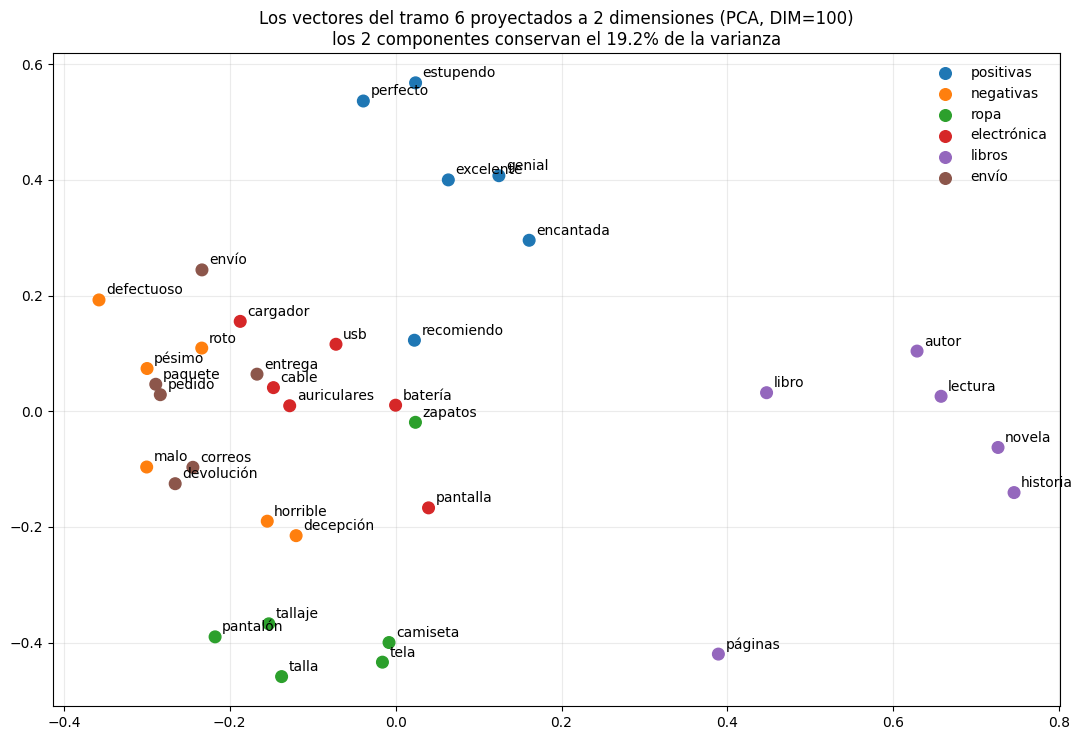

In [12]:
grupos = {
    "positivas":    ["excelente", "perfecto", "genial", "recomiendo", "encantada", "estupendo"],
    "negativas":    ["pésimo", "horrible", "malo", "decepción", "defectuoso", "roto"],
    "ropa":         ["talla", "camiseta", "tallaje", "pantalón", "zapatos", "tela"],
    "electrónica":  ["batería", "cargador", "usb", "pantalla", "cable", "auriculares"],
    "libros":       ["libro", "autor", "novela", "lectura", "páginas", "historia"],
    "envío":        ["envío", "entrega", "paquete", "correos", "devolución", "pedido"],
}

etiquetas, colores, filas = [], [], []
for color, (grupo, palabras) in zip(plt.cm.tab10.colors, grupos.items()):
    for p in palabras:
        if p in vocab.stoi:
            etiquetas.append(p)
            colores.append(color)
            filas.append(E[vocab[p]])

X = torch.stack(filas)
X = X - X.mean(dim=0, keepdim=True)
U, S_, Vt = torch.pca_lowrank(X, q=2)
Y = (X @ Vt[:, :2]).numpy()
var = (S_[:2] ** 2).sum().item() / (X ** 2).sum().item()   # varianza conservada

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.scatter(Y[:, 0], Y[:, 1], c=colores, s=70, zorder=3)
for (x, y), p in zip(Y, etiquetas):
    ax.annotate(p, (x, y), fontsize=10, xytext=(5, 4), textcoords="offset points")
for color, grupo in zip(plt.cm.tab10.colors, grupos):
    ax.scatter([], [], c=[color], s=70, label=grupo)
ax.legend(loc="best", frameon=False)
ax.set_title(f"Los vectores del tramo 6 proyectados a 2 dimensiones (PCA, DIM={DIM})\n"
             f"los 2 componentes conservan el {var:.1%} de la varianza")
ax.grid(alpha=0.25, zorder=0)
plt.tight_layout()
plt.show()

Tres lecturas de la proyección, en orden creciente de sorpresa:

- **El grupo de los libros queda aislado a la derecha**, y es el más definido de los seis. Es
  esperable: son reseñas de un producto que se describe con un vocabulario que no comparte con
  ningún otro. La ropa, abajo, forma otro grupo compacto, con *zapatos* como única excepción.
- **Las palabras de envío no forman un grupo propio: quedan entre las negativas.** *Correos*,
  *devolución*, *paquete* y *pedido* aparecen entre *malo*, *roto*, *pésimo* y *defectuoso*. No hay
  nada programado al respecto: en un corpus de reseñas de productos casi nadie escribe sobre el
  envío cuando todo salió bien. La logística aparece en las quejas, y el modelo lo estimó del texto.
- **La electrónica queda dispersa por el centro.** Es el grupo peor definido de los seis, en parte
  porque sus palabras aparecen en reseñas de cualquier producto.

Y la advertencia que corresponde a toda proyección: los dos componentes conservan la fracción de la
varianza que indica el título, de modo que buena parte de la estructura no está en la figura. Lo
que se observa alcanza para orientarse; lo que **no** se observa no prueba nada.

Con esto queda cubierto cómo se producen los vectores. **Fin del tramo 6.**

---

## 7. Lo que se usa en la práctica: vectores preentrenados

Los vectores del tramo 6 se estimaron a partir de 1.556.230 tokens de reseñas de productos. Sirven
para exhibir el mecanismo y dentro de ese dominio son razonables, pero tienen dos límites: el
vocabulario es de 7.067 tokens y todo lo que representan proviene de reseñas de compras por
internet.

Lo que se hace en la práctica, entonces, es **no entrenar los vectores**. Otros ya ejecutaron este
mismo procedimiento sobre miles de millones de palabras —Wikipedia completa, volcados de la web, y
para varios idiomas— y publicaron la tabla resultante, que se descarga y se usa. Es la primera
forma de *transferencia* que aparece en la materia: aprovechar el cómputo hecho por otros sobre
datos que uno no tiene.

Las tres familias más citadas:

**word2vec** (2013) es lo del tramo 6: *skip-gram* o CBOW, con muestreo negativo. Es el que
inauguró la línea.

**GloVe** (2014) vuelve a la matriz de co-ocurrencia del tramo 3, en vez de recorrer el corpus par
por par. Ajusta los vectores para que el producto punto de dos palabras aproxime el logaritmo de
sus co-ocurrencias, de manera que las **razones** entre co-ocurrencias queden bien representadas.
De ahí lo de *global*: usa estadísticas del corpus entero de una vez, y no una ventana por vez.
En calidad de los vectores queda a la par de *word2vec*.

**fastText** (2016) incorpora **morfología**. En vez de estimar un vector por palabra, estima uno
por cada $n$-grama de 3 a 6 caracteres, y el vector de una palabra es la suma de los vectores de
sus $n$-gramas. Eso le da dos ventajas en un idioma como el español: *duradera*, *duradero* y
*duración* comparten $n$-gramas, así que comparten señal; y una palabra **que nunca apareció en el
entrenamiento** —un error de tipeo, un nombre de producto— igual recibe un vector, porque sus
$n$-gramas sí aparecieron. Es el que se usa en el laboratorio.

La diferencia de escala pesa más que la de método: el vocabulario pasa de los 7.067 tokens del
tramo 6 a cientos de miles, y cambia el dominio, porque los vectores de fastText en español
representan también política, biología o deporte, y no solo envíos y devoluciones.

---

## 8. El puente al Laboratorio 1c

El laboratorio parte de **dos tablas de vectores** definidas sobre el mismo vocabulario —el del
corpus completo de reseñas, 15.548 tokens— y con la misma forma, $15.548 \times 300$:

| | De dónde sale | Con qué señal se entrenó |
|---|---|---|
| **Tabla supervisada** | La capa `nn.Embedding` del clasificador de estrellas que entrena el propio laboratorio | Predecir la cantidad de estrellas de la reseña, sobre 6,2 millones de tokens |
| **Tabla de propósito general** | fastText en español, descargada | Predecir contextos, sobre miles de millones de palabras |

Las dos le asignan a cada palabra una fila de 300 componentes y las dos se llaman *embeddings*. De
las dos, hasta acá viste solamente la primera: la tabla del clasificador de la Parte B es la única
con la que trabajaste, y es un subproducto de una tarea que no se propone representar el
significado en general.

La pregunta del laboratorio es si las dos tablas representan lo mismo, y la respuesta no es
evidente. El clasificador de estrellas alcanza el 55,1% de *accuracy* sobre cinco clases
balanceadas, contra el 20% del azar, así que algo aprendió sobre las palabras. La pregunta es
**qué**, y si eso que aprendió se parece a lo que contiene una tabla de propósito general.

El laboratorio lo mide de cuatro maneras: los vecinos de cada tabla lado a lado, la geometría de
cada una, las dos nubes proyectadas a 2 dimensiones y una prueba de transferencia con pocos datos.
El resultado no es el que se anticipa antes de ejecutarlo.

Una advertencia metodológica que el laboratorio repite: las dos tablas no difieren solo en la tarea
con la que se entrenaron, sino también en el corpus. Con este diseño no hay manera de separar los
dos efectos, y esa limitación no se disimula: forma parte de lo que hay que discutir al interpretar
los resultados.

---

## 9. Tres límites que conviene tener presentes

Todo el procedimiento de esta clase produce **un vector fijo por palabra**. De ahí se siguen tres
límites, que no son defectos de implementación:

**Una palabra, un vector.** *Banco* tiene una sola fila, que combina el sentido de asiento y el de
entidad financiera en una representación única, ponderada por la frecuencia de cada uso. Ninguno de
los dos sentidos queda bien representado, y no hay forma de corregirlo dentro de este esquema. Resolverlo requiere que el vector dependa de la oración en la
que la palabra aparece, que es exactamente lo que hacen los modelos contextuales de las unidades
que siguen.

**Lo que estaba en el texto queda en los vectores.** Si en el corpus ciertas profesiones aparecen
sistemáticamente en contextos masculinos, esa asociación queda codificada en la geometría y se
puede medir con el mismo coseno con el que se midieron *café* y *té*. No es una anomalía: es la
hipótesis distribucional funcionando sobre un corpus que refleja quién escribió qué. Un modelo
entrenado sobre estos vectores hereda eso.

**Los antónimos.** El caso apareció dos veces en esta clase, con dos métodos distintos, y es el
límite más difícil de explicar a quien ve los vectores por primera vez: *caro* y *barato* resultan
parecidos porque **son** parecidos desde el punto de vista distribucional. Si una aplicación
necesita distinguirlos, la señal tiene que provenir de otra fuente.

---

## Síntesis

1. El *one-hot* hace a todas las palabras equidistantes, y eso impide generalizar entre palabras
   parecidas.
2. Un *embedding* es una **fila de una tabla** de $V \times d$, y la pregunta es qué valores le
   corresponden.
3. La **hipótesis distribucional** dice que esos números pueden salir de con quién aparece cada
   palabra, sin que nadie anote nada.
4. Se puede aplicar **contando** (matriz de co-ocurrencia) o **prediciendo** (*skip-gram*). La
   segunda vía es la que se impuso, y el vector es un **subproducto**: el clasificador se descarta.
5. El **muestreo negativo** cambia una pregunta de $V$ clases por una binaria, y es lo que vuelve
   el entrenamiento computable.
6. En la práctica los vectores **se descargan**, no se entrenan.
7. Todo el procedimiento produce un vector fijo por palabra, y de ahí se siguen sus tres límites.

Lo que sigue es el **Laboratorio 1c**.